In [1]:
# notebook for plotting the promoters containing HNF Family TF binding sites called by the seqlets for comparing the seqlets called by each method

In [31]:
# import packages
import pandas as pd
import matplotlib.pyplot as mpl
import matplotlib
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import torch
import re
import numpy as np
from scipy import stats
import pickle
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
# logomaker
import logomaker

In [2]:
# open all MPAC seqlet calls
# k562
mpac_k_seqlet_calls = pd.read_csv('../mpac/processed_data/mpac_k562_seqlet_calls.tsv', sep = '\t')
mpac_k_full_ann_seqlets = pd.read_csv('../mpac/processed_data/mpac_k562_full_ann_seqlets.tsv', sep = '\t')
with open('../mpac/processed_data/mpac_k562_plotLogo_dict.pkl', 'rb') as f:
    mpac_k_plotLogo_dict = pickle.load(f)
# hepg2
mpac_h_seqlet_calls = pd.read_csv('../mpac/processed_data/mpac_hepg2_seqlet_calls.tsv', sep = '\t')
mpac_h_full_ann_seqlets = pd.read_csv('../mpac/processed_data/mpac_hepg2_full_ann_seqlets.tsv', sep = '\t')
with open('../mpac/processed_data/mpac_hepg2_plotLogo_dict.pkl', 'rb') as f:
    mpac_h_plotLogo_dict = pickle.load(f)
# sknsh
mpac_s_seqlet_calls = pd.read_csv('../mpac/processed_data/mpac_sknsh_seqlet_calls.tsv', sep = '\t')
mpac_s_full_ann_seqlets = pd.read_csv('../mpac/processed_data/mpac_sknsh_full_ann_seqlets.tsv', sep = '\t')
with open('../mpac/processed_data/mpac_sknsh_plotLogo_dict.pkl', 'rb') as f:
    mpac_s_plotLogo_dict = pickle.load(f)

In [7]:
# open all MPAC predictions for getting some summary numbers
all_mpac_preds = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.tsv', sep = '\t')

In [10]:
all_mpac_preds.filter(['id'] + [i for i in all_mpac_preds.keys() if 'k562' in i or 'hepg2' in i or 'sknsh' in i]).head()

,id,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred,...,sknsh_mean_ref,k562_mean_active,hepg2_mean_active,sknsh_mean_active,k562_emVar,hepg2_emVar,sknsh_emVar,k562_rna_tpm,hepg2_rna_tpm,sknsh_rna_tpm
0,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,0.368796,0.382817,0.014021,0.367238,0.361899,-0.005339,0.558187,0.547707,-0.010479,...,0.241022,0,0,0,0,0,0,0.0,0.0,0.0
1,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,0.368796,0.373723,0.004927,0.367238,0.363106,-0.004132,0.558187,0.539187,-0.019000,...,0.241022,0,0,0,0,0,0,0.0,0.0,0.0
2,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,0.368796,0.355564,-0.013233,0.367238,0.344585,-0.022653,0.558187,0.530182,-0.028004,...,0.241022,0,0,0,0,0,0,0.0,0.0,0.0
3,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,0.287499,0.341029,0.053531,0.352586,0.411632,0.059047,0.538484,0.640290,0.101806,...,0.241022,0,0,0,0,0,0,0.0,0.0,0.0
4,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,0.287499,0.300818,0.013319,0.352586,0.341317,-0.011269,0.538484,0.505176,-0.033308,...,0.241022,0,0,0,0,0,0,0.0,0.0,0.0


In [13]:
# group predictions at the promoter level
mpac_promoter_means = all_mpac_preds.filter(['id'] + [i for i in all_mpac_preds.keys() if 'k562' in i or 'hepg2' in i or 'sknsh' in i]).groupby('id').mean().reset_index()
# break out gene name
mpac_promoter_means.loc[:,'ensgID'] = [i.split('_')[0] for i in mpac_promoter_means['id']]

In [14]:
# get info for each highlighted promoter
# CCR10, ENSG00000184451.5
mpac_promoter_means[mpac_promoter_means['ensgID'] == 'ENSG00000184451.5']
# mpac predictions (mean ref)
# k562: 1.334515
# hepg2: 1.16829
# sknsh: 1.232508
# RNA expression
# k562: 4.4 TPM
# hepg2: 0.8 TPM
# sknsh: 2.1 TPM

,id,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred,...,k562_mean_active,hepg2_mean_active,sknsh_mean_active,k562_emVar,hepg2_emVar,sknsh_emVar,k562_rna_tpm,hepg2_rna_tpm,sknsh_rna_tpm,ensgID
13855,ENSG00000184451.5_ENST00000332438.4_CCR10..chr...,1.334515,1.295546,-0.038969,1.16829,1.13019,-0.038099,1.232508,1.198308,-0.0342,...,1.0,1.0,1.0,0.130667,0.085333,0.092,4.4,0.8,2.1,ENSG00000184451.5


In [19]:
# get info for each highlighted promoter
# LDLR, ENSG00000130164.15
mpac_promoter_means[mpac_promoter_means['ensgID'] == 'ENSG00000130164.15']
# mpac predictions (mean ref)
# k562: 2.210465
# hepg2: 1.616229
# sknsh: 1.782087
# RNA expression
# k562: 42.1 TPM
# hepg2: 43.1 TPM
# sknsh: 19.1 TPM

,id,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred,...,k562_mean_active,hepg2_mean_active,sknsh_mean_active,k562_emVar,hepg2_emVar,sknsh_emVar,k562_rna_tpm,hepg2_rna_tpm,sknsh_rna_tpm,ensgID
5588,ENSG00000130164.15_ENST00000558518.6_LDLR..chr...,2.210465,2.101368,-0.109097,1.616229,1.548639,-0.06759,1.782087,1.712274,-0.069813,...,1.0,1.0,1.0,0.124498,0.093708,0.104418,42.1,43.1,19.1,ENSG00000130164.15


In [16]:
# get info for each highlighted promoter
# TNKS2, ENSG00000107854.7
mpac_promoter_means[mpac_promoter_means['ensgID'] == 'ENSG00000107854.7']
# mpac predictions (mean ref)
# k562: 3.831952
# hepg2: 3.649107
# sknsh: 4.962888
# RNA expression
# k562: 12.5 TPM
# hepg2: 15.6 TPM
# sknsh: 20.6 TPM

,id,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred,...,k562_mean_active,hepg2_mean_active,sknsh_mean_active,k562_emVar,hepg2_emVar,sknsh_emVar,k562_rna_tpm,hepg2_rna_tpm,sknsh_rna_tpm,ensgID
3075,ENSG00000107854.7_ENST00000371627.5_TNKS2..chr...,3.831952,3.755018,-0.076933,3.649107,3.588755,-0.060352,4.962888,4.872043,-0.090845,...,1.0,1.0,1.0,0.12,0.068,0.129333,12.5,15.6,20.6,ENSG00000107854.7


In [70]:
def plot_specific_logos_mpac_stranded (seqlets,
                                       annotated_seqlets,
                                       promoter_id,
                                       gene_name,
                                       plotLogo_tensors,
                                       cell,
                                       model,
                                       promoter_strand,
                                       output):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    # make a dictionary for annotating seqlets calls with promoters
    promoter_idx = list(plotLogo_tensors.keys()).index(promoter_id)
    # filter for the random enhancer by enhancer index
    pro_seqlets = seqlets[seqlets['example_idx'] == promoter_idx]
    pro_ann = annotated_seqlets.iloc[pro_seqlets.index]
    # check strand and reverse as necessary
    if promoter_strand == '-':
        # flip the attributions
        tensors2plot = torch.flip(plotLogo_tensors[promoter_id], dims=(1,))
        # refactor the seqlets
        pro_seqlets.loc[:,'start'] = 249 - pro_seqlets['start']
        pro_seqlets.loc[:,'end'] = 249 - pro_seqlets['end']
        # refactor the annotations
        pro_ann.loc[:,'start'] = 249 - pro_ann['start']
        pro_ann.loc[:,'end'] = 249 - pro_ann['end']
        # get the minimum and maximum attributions for plotting
        minAttrib = tensors2plot.min().min() * 1.05
        maxAttrib = tensors2plot.max().max() * 1.05
    else:
        tensors2plot = plotLogo_tensors[promoter_id]
        minAttrib = tensors2plot.min().min() * 1.05
        maxAttrib = tensors2plot.max().max() * 1.05
    if len(pro_ann) > 0:
        #ax = mpl.subplot(111)
        dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy() # convert tensor to DF for plotting with logoMaker
        renamedDF = dfFromTensor.rename(columns={0 : 'A', 1 : 'C', 2 : 'G', 3 : 'T'})
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        logoCheck = logomaker.Logo(renamedDF, figsize=[7,1])
        logoCheck.style_spines(visible=False)
        #plot_logo(tensors2plot)#, annotations=pro_ann, score_key='attribution')
        for idx, row in pro_ann.iterrows():
            start, stop, tf = row[['start', 'end', 'example_idx']].tolist() # add attribution score to plot for annotating TFs
            if promoter_strand == '-':
                #logoCheck.highlight_position_range(pmin= stop, pmax=start, alpha=0.15, color=highlight)
                #logoCheck.ax.plot([stop, start],
                #[maxAttrib*0.5, maxAttrib*0.5], color='k', linewidth=1, solid_capstyle='butt')
                #logoCheck.ax.text((stop+start) / 2,maxAttrib*0.85,f'${tf.split('_')[0]}$',fontsize=12,verticalalignment='top', horizontalalignment='center')
                logoCheck.ax.set_xlim([0, 250])
                logoCheck.ax.set_xticks([0, 50, 100, 150, 200, 250], [-250, -200, -150, -100, -50, 0])
                logoCheck.ax.set_ylim([minAttrib * 1.2, maxAttrib * 1.2])
                logoCheck.ax.set_ylabel('Attribution')
                logoCheck.ax.set_xlabel('Distance from TSS')
                #logoCheck.ax.axhline(minAttrib * 1.1, color='k', linewidth=0.5)
            else:
                #logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.15, color=highlight)
                #logoCheck.ax.plot([start, stop],
                #[maxAttrib*0.5, maxAttrib*0.5], color='k', linewidth=1, solid_capstyle='butt')
                #logoCheck.ax.text((stop+start) / 2,maxAttrib*0.85,f'${tf.split('_')[0]}$',fontsize=12,verticalalignment='top', horizontalalignment='center')
                logoCheck.ax.set_xlim([0, 250])
                logoCheck.ax.set_xticks([0, 50, 100, 150, 200, 250], [-250, -200, -150, -100, -50, 0])
                logoCheck.ax.set_ylim([minAttrib * 1.2, maxAttrib * 1.2])
                logoCheck.ax.set_ylabel('Attribution')
                logoCheck.ax.set_xlabel('Distance from TSS')
        #mpl.ylim(-.5, .5)
        mpl.title(f'{model} {cell} | {promoter_id}, {gene_name}')
        #mpl.tight_layout()
        mpl.savefig(output, dpi=300, bbox_inches='tight')
    else:
        dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy() # convert tensor to DF for plotting with logoMaker
        renamedDF = dfFromTensor.rename(columns={0 : 'A', 1 : 'C', 2 : 'G', 3 : 'T'})
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        logoCheck = logomaker.Logo(renamedDF, figsize=[7,1])
        logoCheck.style_spines(visible=False)
        if promoter_strand == '-':
                #logoCheck.highlight_position_range(pmin= stop, pmax=start, alpha=0.15, color=highlight)
                #logoCheck.ax.plot([stop, start],
                #[maxAttrib*0.5, maxAttrib*0.5], color='k', linewidth=1, solid_capstyle='butt')
                #logoCheck.ax.text((stop+start) / 2,maxAttrib*0.85,f'${tf.split('_')[0]}$',fontsize=12,verticalalignment='top', horizontalalignment='center')
                logoCheck.ax.set_xlim([0, 250])
                logoCheck.ax.set_xticks([0, 50, 100, 150, 200, 250], [-250, -200, -150, -100, -50, 0])
                logoCheck.ax.set_ylim([minAttrib * 1.2, maxAttrib * 1.2])
                logoCheck.ax.set_ylabel('Attribution')
                logoCheck.ax.set_xlabel('Distance from TSS')
        else:
                #logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.15, color=highlight)
                #logoCheck.ax.plot([start, stop],
                #[maxAttrib*0.5, maxAttrib*0.5], color='k', linewidth=1, solid_capstyle='butt')
                #logoCheck.ax.text((stop+start) / 2,maxAttrib*0.85,f'${tf.split('_')[0]}$',fontsize=12,verticalalignment='top', horizontalalignment='center')
                logoCheck.ax.set_xlim([0, 250])
                logoCheck.ax.set_xticks([0, 50, 100, 150, 200, 250], [-250, -200, -150, -100, -50, 0])
                logoCheck.ax.set_ylim([minAttrib * 1.2, maxAttrib * 1.2])
                logoCheck.ax.set_ylabel('Attribution')
                logoCheck.ax.set_xlabel('Distance from TSS')
        #mpl.ylim(-.5, .5)
        mpl.title(f'{model} {cell} | {promoter_id}, {gene_name}')
        #mpl.tight_layout()
        mpl.savefig(output, dpi=300, bbox_inches='tight')

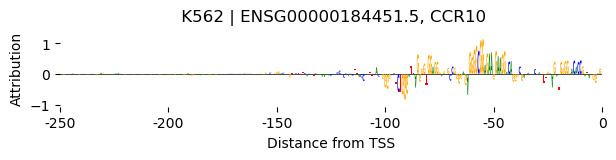

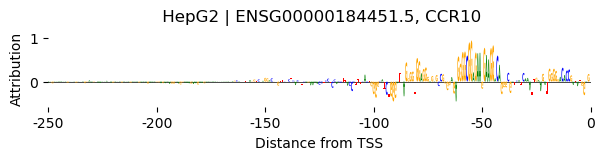

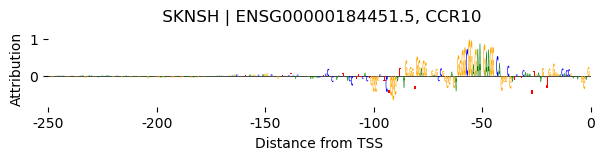

In [76]:
# ENSG00000184451.5 CCR10
# k562
plot_specific_logos_mpac_stranded(
    mpac_k_seqlet_calls,
    mpac_k_full_ann_seqlets,
    'ENSG00000184451.5',
    'CCR10',
    mpac_k_plotLogo_dict,
    'K562',
    '',
    '-',
    '../figures/CCR10_K562_contributions.pdf'
)
# hepg2
plot_specific_logos_mpac_stranded(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000184451.5',
    'CCR10',
    mpac_h_plotLogo_dict,
    'HepG2',
    '',
    '-',
    '../figures/CCR10_HepG2_contributions.pdf'
)
# sknsh
plot_specific_logos_mpac_stranded(
    mpac_s_seqlet_calls,
    mpac_s_full_ann_seqlets,
    'ENSG00000184451.5',
    'CCR10',
    mpac_s_plotLogo_dict,
    'SKNSH',
    '',
    '-',
    '../figures/CCR10_SKNSH_contributions.pdf'
)

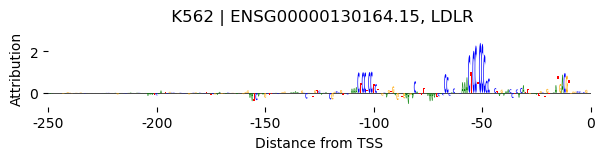

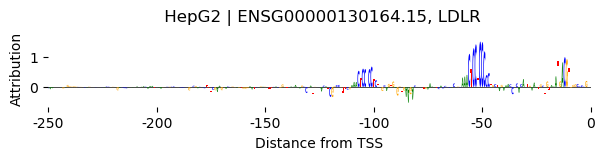

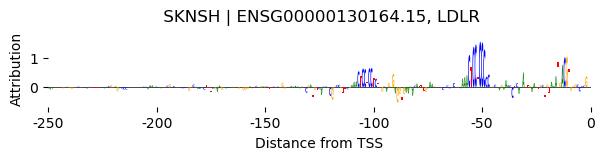

In [77]:
# ENSG00000130164.15 LDLR
# k562
plot_specific_logos_mpac_stranded(
    mpac_k_seqlet_calls,
    mpac_k_full_ann_seqlets,
    'ENSG00000130164.15',
    'LDLR',
    mpac_k_plotLogo_dict,
    'K562',
    '',
    '+',
    '../figures/LDLR_K562_contributions.pdf'
)
# hepg2
plot_specific_logos_mpac_stranded(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000130164.15',
    'LDLR',
    mpac_h_plotLogo_dict,
    'HepG2',
    '',
    '+',
    '../figures/LDLR_HepG2_contributions.pdf'
)
# sknsh
plot_specific_logos_mpac_stranded(
    mpac_s_seqlet_calls,
    mpac_s_full_ann_seqlets,
    'ENSG00000130164.15',
    'LDLR',
    mpac_s_plotLogo_dict,
    'SKNSH',
    '',
    '+',
    '../figures/LDLR_SKNSH_contributions.pdf'
)

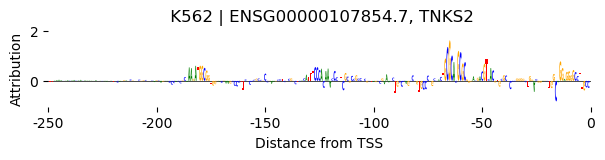

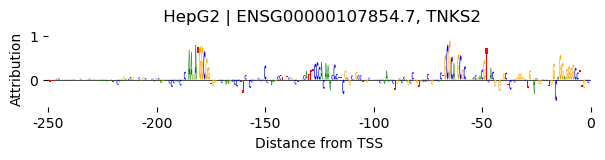

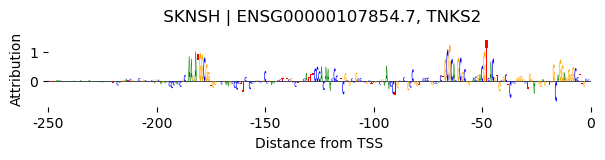

In [78]:
# TNKS2 ENSG00000107854.7
# k562
plot_specific_logos_mpac_stranded(
    mpac_k_seqlet_calls,
    mpac_k_full_ann_seqlets,
    'ENSG00000107854.7',
    'TNKS2',
    mpac_k_plotLogo_dict,
    'K562',
    '',
    '+',
    '../figures/TNKS2_K562_contributions.pdf'
)
# hepg2
plot_specific_logos_mpac_stranded(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000107854.7',
    'TNKS2',
    mpac_h_plotLogo_dict,
    'HepG2',
    '',
    '+',
    '../figures/TNKS2_HepG2_contributions.pdf'
)
# sknsh
plot_specific_logos_mpac_stranded(
    mpac_s_seqlet_calls,
    mpac_s_full_ann_seqlets,
    'ENSG00000107854.7',
    'TNKS2',
    mpac_s_plotLogo_dict,
    'SKNSH',
    '',
    '+',
    '../figures/TNKS2_SKNSH_contributions.pdf'
)